In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
np.random.seed(101)
n_campaigns = 180

# Ad spend in thousands ($k) across marketing channels
ad_spend = np.random.uniform(5.0, 50.0, size=n_campaigns)

# Base baseline revenue + linear conversion rate + market variance
noise = np.random.normal(loc=0, scale=14.0, size=n_campaigns)
revenue = 4.2 * ad_spend + 45.0 + noise

df = pd.DataFrame({
    "Ad_Spend_k": np.round(ad_spend, 2),
    "Revenue_k": np.round(revenue, 2)
})
df.head()

,Ad_Spend_k,Revenue_k
0,28.24,161.16
1,30.68,184.78
2,6.28,66.02
3,12.72,92.69
4,35.84,200.33


In [3]:
X = df[["Ad_Spend_k"]]
y = df["Revenue_k"]

model = LinearRegression()
model.fit(X, y)

df["Predicted_Revenue_k"] = model.predict(X)
df["Residual"] = df["Revenue_k"] - df["Predicted_Revenue_k"]

# Performance metrics
ss_res = np.sum(df["Residual"]**2)
ss_tot = np.sum((df["Revenue_k"] - df["Revenue_k"].mean())**2)
r2 = 1 - (ss_res / ss_tot)
mae = np.mean(np.abs(df["Residual"]))

print(f"Revenue Multiplier (Slope): {model.coef_[0]:.2f}x")
print(f"Baseline Revenue (Intercept): ${model.intercept_:.2f}k")
print(f"R² Score:                    {r2:.3f}")
print(f"Mean Absolute Error (MAE):   ${mae:.2f}k")

Revenue Multiplier (Slope): 4.37x
Baseline Revenue (Intercept): $40.26k
R² Score:                    0.936
Mean Absolute Error (MAE):   $11.68k


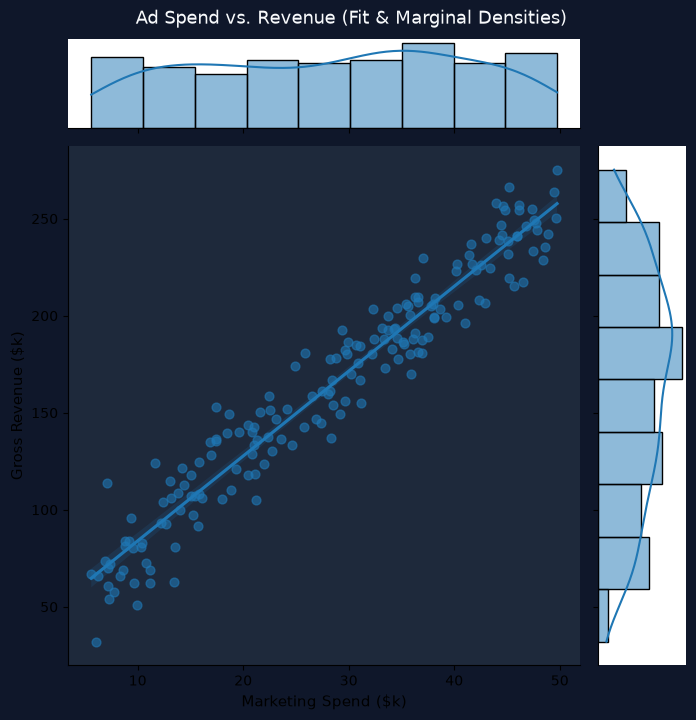

In [4]:
g = sns.jointplot(
    data=df,
    x="Ad_Spend_k",
    y="Revenue_k",
    kind="reg",
    joint_kws={
        "scatter_kws": {"alpha": 0.6, "s": 40},
    },
    height=7
)

g.figure.patch.set_facecolor("#0f172a")
g.ax_joint.set_facecolor("#1e293b")
g.set_axis_labels("Marketing Spend ($k)", "Gross Revenue ($k)", fontsize=11)
plt.suptitle("Ad Spend vs. Revenue (Fit & Marginal Densities)", y=1.02, color="#f8fafc", fontsize=13)
plt.show()

In [ ]:
# import pandas as pd

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

In [14]:
# dir(sns)

In [13]:
# dir(pd)

In [ ]:
# data = {
#     'X':[1, 2, 3, 4, 5],
#     'Y':[22, 24, 27, 30, 36]
# }
# df=pd.DataFrame(data)
# print(df)

   X   Y
0  1  22
1  2  24
2  3  27
3  4  30
4  5  36


In [ ]:
# sns.regplot(x='X', y='Y', data=df)
# plt.xlabel("X")
# plt.ylabel("Y")
# plt.title("Linear Regression")
# plt.show()

In [12]:
# sns.regplot?

In [ ]:
# x=df['X']
# y=df['Y']
# n=len(df)
# b1=(n*(x*y).sum()-x.sum()*y.sum())/(n*(x**2).sum()-x.sum()**2)

# b0=(y.sum()-b1*x.sum())/n

# print("Slope =",b1)
# print("Intercept=",b0)
# print("Regression Equation:")
# print("y=",b0,"+",b1,"x")

Slope = 3.4
Intercept= 17.6
Regression Equation:
y= 17.6 + 3.4 x
